In [41]:
# =========================
# Project: Trader Behavior vs Market Sentiment
# Candidate: Yash Vijay Dixit
# Notebook: 1 - Data Cleaning & EDA
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


# Load datasets
trades_df = pd.read_csv("/content/historical_data.csv")
sentiment_df = pd.read_csv("/content/fear_greed_index.csv")

# Quick sanity check
print(trades_df.shape)
print(sentiment_df.shape)

trades_df.head(), sentiment_df.head()



(211224, 16)
(2644, 4)


(                                      Account  Coin  Execution Price  \
 0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
 1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
 2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
 3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
 4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
 
    Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
 0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
 1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
 2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
 3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
 4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   
 
    Closed PnL                                   Transaction Hash     Order ID  \
 0      

In [42]:
# Inspect columns
print(trades_df.columns)
print(sentiment_df.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [45]:
# Create a copy first to ensure we are working on an independent DataFrame and avoid SettingWithCopyWarning
sentiment_df = sentiment_df.copy()

# Convert Date column to datetime
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Keep only required columns and rename 'classification' to 'sentiment'
sentiment_df = sentiment_df[['date', 'classification']].copy()
sentiment_df.rename(columns={'classification': 'sentiment'}, inplace=True)

# Check result
sentiment_df.head()

,date,sentiment
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear


In [46]:
sentiment_df['sentiment'].value_counts()


,count
sentiment,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [47]:
# Inspect timestamp columns in trades_df
print(trades_df['Timestamp IST'].head())
print(trades_df['Timestamp IST'].dtype)
print(trades_df['Timestamp'].head())
print(trades_df['Timestamp'].dtype)


0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object
object
0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
float64


In [48]:
# Map detailed sentiment into binary Fear / Greed
sentiment_mapping = {
    'Fear': 'Fear',
    'Extreme Fear': 'Fear',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
}

sentiment_df['sentiment'] = sentiment_df['sentiment'].map(sentiment_mapping)


In [49]:
# Drop Neutral sentiment rows
sentiment_df = sentiment_df.dropna(subset=['sentiment'])


In [50]:
sentiment_df['sentiment'].value_counts()


,count
sentiment,
Fear,1289
Greed,959


In [51]:
import os

# Create the directory if it does not exist
os.makedirs('csv_files', exist_ok=True)
os.makedirs("outputs", exist_ok=True)


sentiment_df.to_csv("csv_files/sentiment_daily.csv", index=False)

In [52]:
sentiment_df.to_csv("csv_files/sentiment_daily.csv", index=False)


In [53]:
trades_df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [54]:
trades_df = trades_df.rename(columns={
    'Account': 'account',
    'Coin': 'symbol',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp IST': 'timestamp',
    'Closed PnL': 'closed_pnl'
})


In [55]:
print(trades_df.columns)


Index(['account', 'symbol', 'execution_price', 'size_tokens', 'size_usd',
       'side', 'timestamp', 'Start Position', 'Direction', 'closed_pnl',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [56]:
# Convert timestamp to datetime
trades_df['timestamp'] = pd.to_datetime(trades_df['timestamp'], format='%d-%m-%Y %H:%M')

# Extract date
trades_df['date'] = trades_df['timestamp'].dt.date
trades_df['date'] = pd.to_datetime(trades_df['date'])

trades_df[['timestamp', 'date']].head()


,timestamp,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [58]:
trades_df['trade_value'] = trades_df['size_usd']


In [57]:
trades_df['win'] = (trades_df['closed_pnl'] > 0).astype(int)


In [59]:
daily_trades = trades_df.groupby('date').agg(
    total_pnl=('closed_pnl', 'sum'),
    total_volume=('trade_value', 'sum'),
    win_rate=('win', 'mean'),
    trade_count=('win', 'count')
).reset_index()

daily_trades.head()


,date,total_pnl,total_volume,win_rate,trade_count
0,2023-05-01,0.000000,477.00,0.000000,3
1,2023-12-05,0.000000,50005.83,0.000000,9
2,2023-12-14,-205.434737,113203.35,0.363636,11
3,2023-12-15,-24.632034,10609.95,0.000000,2
4,2023-12-16,0.000000,15348.77,0.000000,3


In [60]:
daily_trades.describe()


,date,total_pnl,total_volume,win_rate,trade_count
count,480,480.000000,4.800000e+02,480.000000,480.000000
mean,2024-08-25 17:00:00,21451.997799,2.481641e+06,0.366458,440.050000
min,2023-05-01 00:00:00,-419020.225731,1.100000e-01,0.000000,1.000000
25%,2024-04-22 18:00:00,7.253957,9.751021e+04,0.182367,18.000000
50%,2024-08-25 12:00:00,1118.961740,3.272086e+05,0.352779,67.500000
75%,2025-01-01 06:00:00,10669.321765,1.648100e+06,0.503187,520.500000
max,2025-05-01 00:00:00,616413.032233,5.591462e+07,1.000000,6246.000000
std,NaN,71861.463509,6.284835e+06,0.263652,809.748711


In [61]:
daily_trades.to_csv("csv_files/daily_trader_metrics.csv", index=False)


In [62]:
# ============================================================
# STEP 4: MERGE DAILY TRADER METRICS WITH MARKET SENTIMENT
# ============================================================
# Purpose:
# We want to analyze how trader behavior changes depending on
# market sentiment (Fear vs Greed).
#
# To do this, we must combine:
# 1) daily_trades  -> daily trading behavior
# 2) sentiment_df  -> daily market sentiment
#
# The merge key is 'date', because both datasets are daily.
# ============================================================


# -----------------------------
# Sanity check both datasets
# -----------------------------
# Ensure both datasets contain the 'date' column
# and have reasonable sizes before merging.

print("Daily trader data shape:", daily_trades.shape)
print("Sentiment data shape:", sentiment_df.shape)

# Preview first few rows
daily_trades.head(), sentiment_df.head()


# -----------------------------
# Merge datasets on date
# -----------------------------
# We use an INNER JOIN so that we only keep days
# where BOTH trading data and sentiment data exist.
# This avoids incorrect comparisons.

merged_df = pd.merge(
    daily_trades,
    sentiment_df,
    on='date',
    how='inner'
)


# -----------------------------
# Post-merge validation
# -----------------------------
# Check if both Fear and Greed are present
# If only one exists, analysis would be meaningless.

print("Sentiment distribution after merge:")
print(merged_df['sentiment'].value_counts())

# Check final dataset size
print("Merged dataset shape:", merged_df.shape)

# Preview merged data
merged_df.head()



# Save merged dataset



merged_df.to_csv("csv_files/merged_data.csv", index=False)

print("Merged dataset saved successfully.")


Daily trader data shape: (480, 5)
Sentiment data shape: (2248, 2)
Sentiment distribution after merge:
sentiment
Greed    307
Fear     105
Name: count, dtype: int64
Merged dataset shape: (412, 6)
Merged dataset saved successfully.


In [63]:
# ============================================================
# STEP 5A: Sanity check merged dataset
# ============================================================
# Ensure that merged_df contains all required columns
# before starting analysis and plotting.
# ============================================================

print(merged_df.columns)
merged_df.head()


Index(['date', 'total_pnl', 'total_volume', 'win_rate', 'trade_count',
       'sentiment'],
      dtype='object')


,date,total_pnl,total_volume,win_rate,trade_count,sentiment
0,2023-05-01,0.000000,477.00,0.000000,3,Greed
1,2023-12-05,0.000000,50005.83,0.000000,9,Greed
2,2023-12-14,-205.434737,113203.35,0.363636,11,Greed
3,2023-12-15,-24.632034,10609.95,0.000000,2,Greed
4,2023-12-16,0.000000,15348.77,0.000000,3,Greed


<Figure size 800x500 with 0 Axes>

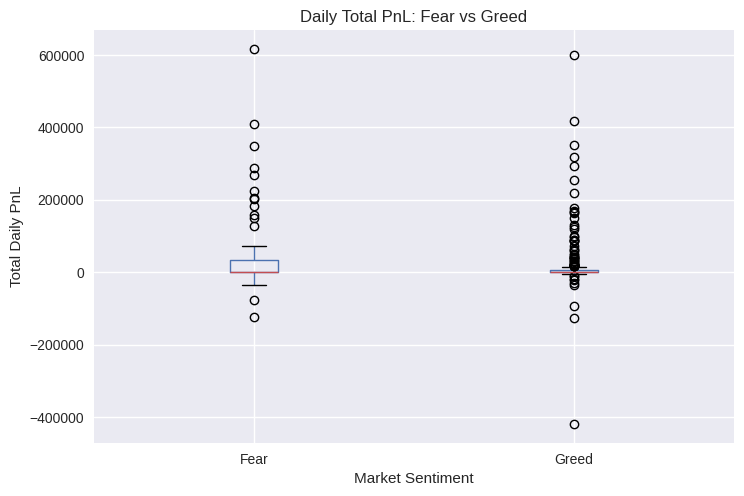

In [64]:
# ============================================================
# STEP 5B: PnL comparison by sentiment
# ============================================================
# This boxplot shows how daily total PnL behaves under
# Fear vs Greed market sentiment.
# ============================================================

plt.figure(figsize=(8, 5))
merged_df.boxplot(column='total_pnl', by='sentiment')
plt.title("Daily Total PnL: Fear vs Greed")
plt.suptitle("")  # Remove default pandas title
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily PnL")
plt.grid(True)

# Save plot
plt.savefig("outputs/pnl_fear_vs_greed.png", bbox_inches="tight")
plt.show()


<Figure size 800x500 with 0 Axes>

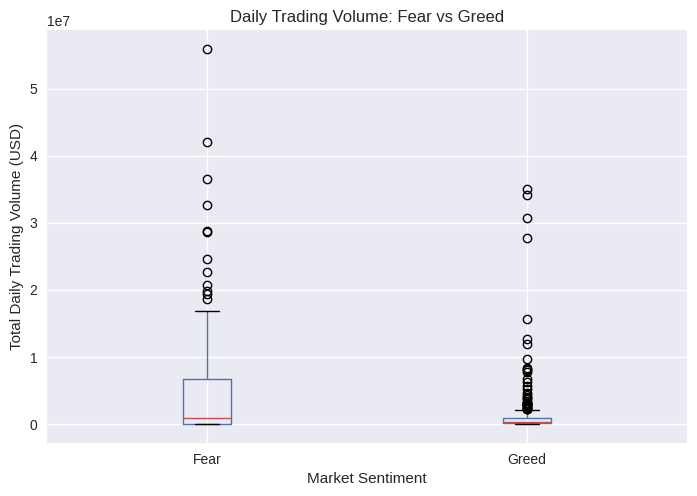

In [65]:
# ============================================================
# STEP 5C: Trading volume comparison by sentiment
# ============================================================

plt.figure(figsize=(8, 5))
merged_df.boxplot(column='total_volume', by='sentiment')
plt.title("Daily Trading Volume: Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Daily Trading Volume (USD)")
plt.grid(True)

# Save plot
plt.savefig("outputs/volume_fear_vs_greed.png", bbox_inches="tight")
plt.show()


<Figure size 800x500 with 0 Axes>

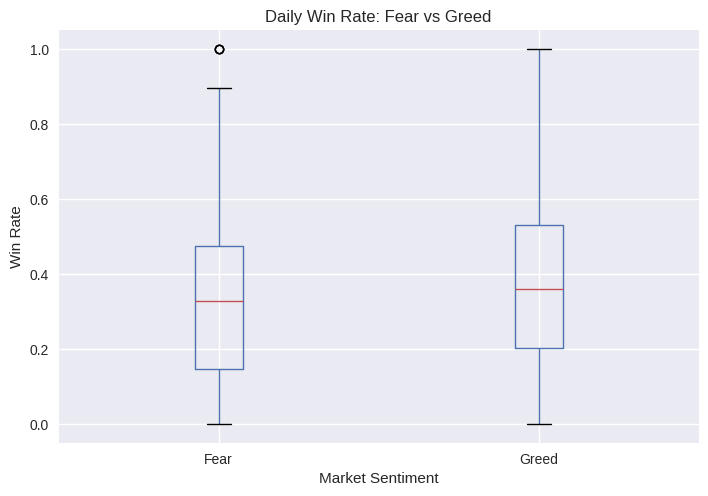

In [66]:
# ============================================================
# STEP 5D: Win rate comparison by sentiment
# ============================================================
# Win rate indicates how often trades are profitable.
# This helps assess trading efficiency under each sentiment.
# ============================================================

plt.figure(figsize=(8, 5))
merged_df.boxplot(column='win_rate', by='sentiment')
plt.title("Daily Win Rate: Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.grid(True)

# Save plot
plt.savefig("outputs/winrate_fear_vs_greed.png", bbox_inches="tight")
plt.show()


<Figure size 800x500 with 0 Axes>

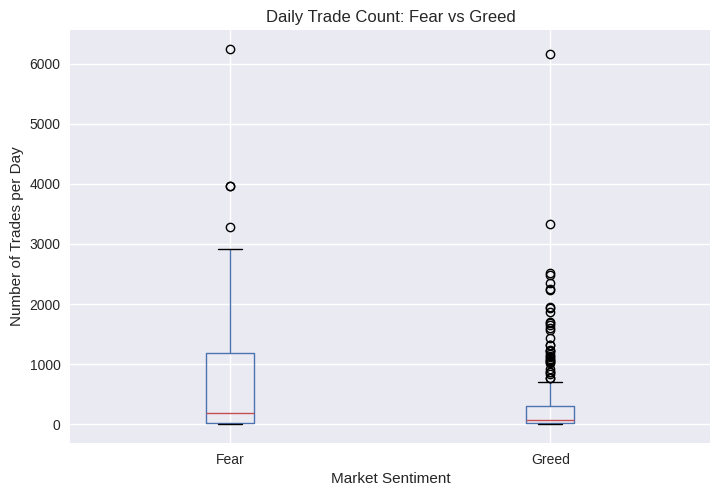

In [67]:
# STEP 5E: Trade count comparison by sentiment
# ============================================================
# Trade count measures market participation and activity.

plt.figure(figsize=(8, 5))
merged_df.boxplot(column='trade_count', by='sentiment')
plt.title("Daily Trade Count: Fear vs Greed")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades per Day")
plt.grid(True)

# Save plot
plt.savefig("outputs/tradecount_fear_vs_greed.png", bbox_inches="tight")
plt.show()


In [68]:
# ============================================================
# STEP 5F: Summary statistics by sentiment
# ============================================================
# This table will be heavily referenced in the final report.
# ============================================================

summary_stats = merged_df.groupby('sentiment').agg(
    avg_pnl=('total_pnl', 'mean'),
    median_pnl=('total_pnl', 'median'),
    avg_volume=('total_volume', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean')
)

summary_stats


,avg_pnl,median_pnl,avg_volume,avg_win_rate,avg_trade_count
sentiment,,,,,
Fear,39012.054192,1876.812082,5.693420e+06,0.328876,792.733333
Greed,15847.884637,1008.619956,1.345432e+06,0.384793,294.120521
